In [4]:
import tensorflow as tf
import pandas as pd
import numpy as np
import os

In [ ]:
os.environ['CUDA_VISIBLE_DEVICES'] = '-1' #reject GPU

In [7]:
def load_dataset(csv_file: str, max_bits: int = 50):
    df = pd.read_csv(csv_file)

    x_raw = df['x'].values.astype(np.int64)
    y = df['y'].values.astype(np.int32)

    x_bin = np.array([[int(bit) for bit in format(num, f'0{max_bits}b')]for num in x_raw], dtype = np.float32)
    
    return x_bin, y


In [12]:
# 输入层为50维的数的二进制表示，输出层为1维的二分类结果（0或1），中间层分别为16，8，4，2个神经元，激活函数维ReLU，输出层激活函数为sigmoid
def build_model(input_dim: int):
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(input_dim,)),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(4, activation='relu'),
        tf.keras.layers.Dense(2, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    #编译模型
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model
        

In [13]:
if __name__ == "__main__":
    train_csv = 'DataSet/train.csv'
    validation_csv = 'DataSet/validation.csv'
    test_csv = 'DataSet/test.csv'

#加载数据
    print("loading dataset...")
    print("loading dataset......")
    print("loading dataset.........")
    print("loading train dataset...")
    print("loading train dataset......")
    print("loading train dataset.........")
    x_train, y_train = load_dataset(train_csv)
    print("loading validation dataset...")
    print("loading validation dataset......")
    print("loading validation dataset.........")
    x_validation, y_validation = load_dataset(validation_csv)
    print("loading test dataset...")
    print("loading test dataset......")
    print("loading test dataset.........")
    x_test, y_test = load_dataset(test_csv)
    print("successfully loaded!!!")


#构建模型
    print("building model...")
    print("building model......")
    print("building model.........")
    model = build_model(input_dim=50)
    model.summary()

#训练模型
    print("training model......")
    history = model.fit(
        x_train, y_train,
        validation_data=(x_validation, y_validation),
        epochs=10,
        batch_size=32,
        verbose=1  #显示训练过程
    )

#评估模型
    print("evaluating model...")
    print("evaluating model......")
    print("evaluating model.........")
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)#评估模型，输出测试集上的损失和准确率
    print(f"Test Accuracy: {test_acc * 100:.2f}%")
    print(f"test_loss:{test_loss:.4f}%")


loading dataset...
loading dataset......
loading dataset.........
loading train dataset...
loading train dataset......
loading train dataset.........
loading validation dataset...
loading validation dataset......
loading validation dataset.........
loading test dataset...
loading test dataset......
loading test dataset.........
successfully loaded!!!
building model...
building model......
building model.........


d:\conda_env\DL_project\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 16)             │           816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,001 (3.91 KB)

 Trainable params: 1,001 (3.91 KB)

 Non-trainable params: 0 (0.00 B)

training model......
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 893us/step - accuracy: 0.9030 - loss: 0.3156 - val_accuracy: 1.0000 - val_loss: 0.0545
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 578us/step - accuracy: 1.0000 - loss: 0.0400 - val_accuracy: 1.0000 - val_loss: 0.0218
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 598us/step - accuracy: 1.0000 - loss: 0.0169 - val_accuracy: 1.0000 - val_loss: 0.0128
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 610us/step - accuracy: 1.0000 - loss: 0.0094 - val_accuracy: 1.0000 - val_loss: 0.0116
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 599us/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 1.0000 - val_loss: 0.0066
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 0.0060
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 632us/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 0.0050
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 623us/step - accuracy: 1.0

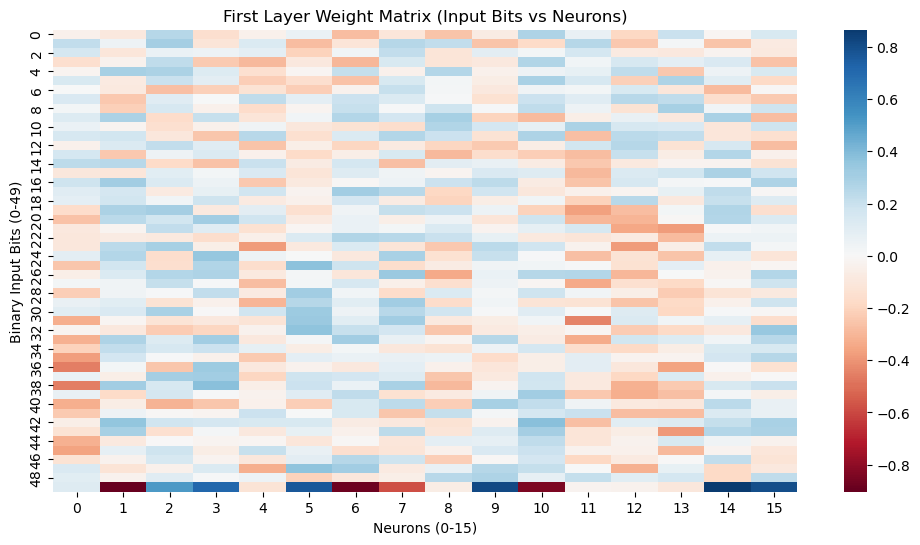

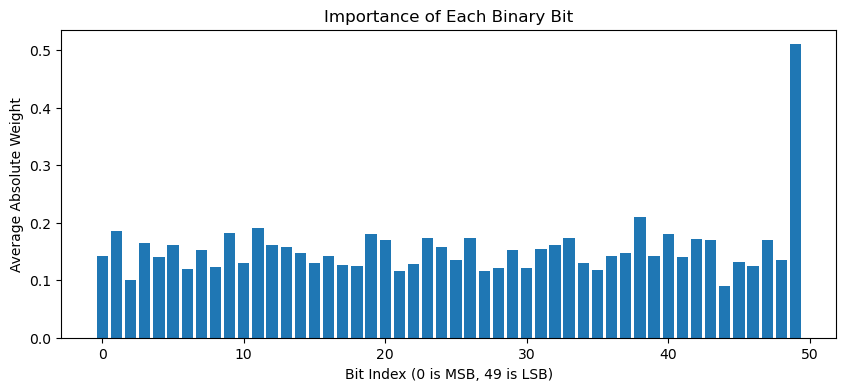

In [14]:
#分析并可视化第一层的权重矩阵
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 获取第一层的权重 (index 0 是第一层)
# weights[0] 是形状为 (50, 16) 的权重矩阵
# weights[1] 是形状为 (16,) 的偏置项
weights = model.layers[0].get_weights()[0]

# 2. 为了直观，我们计算每个输入位（50个位）对下一层所有神经元的平均“贡献度”
# 我们取权重的绝对值，因为负值同样代表重要的特征
importance = np.mean(np.abs(weights), axis=1)

# 3. 可视化权重矩阵
plt.figure(figsize=(12, 6))
sns.heatmap(weights, cmap='RdBu', center=0)
plt.title("First Layer Weight Matrix (Input Bits vs Neurons)")
plt.xlabel("Neurons (0-15)")
plt.ylabel("Binary Input Bits (0-49)")
plt.show()

# 4. 可视化输入位的重要性
plt.figure(figsize=(10, 4))
plt.bar(range(50), importance)
plt.title("Importance of Each Binary Bit")
plt.xlabel("Bit Index (0 is MSB, 49 is LSB)")
plt.ylabel("Average Absolute Weight")
plt.show()

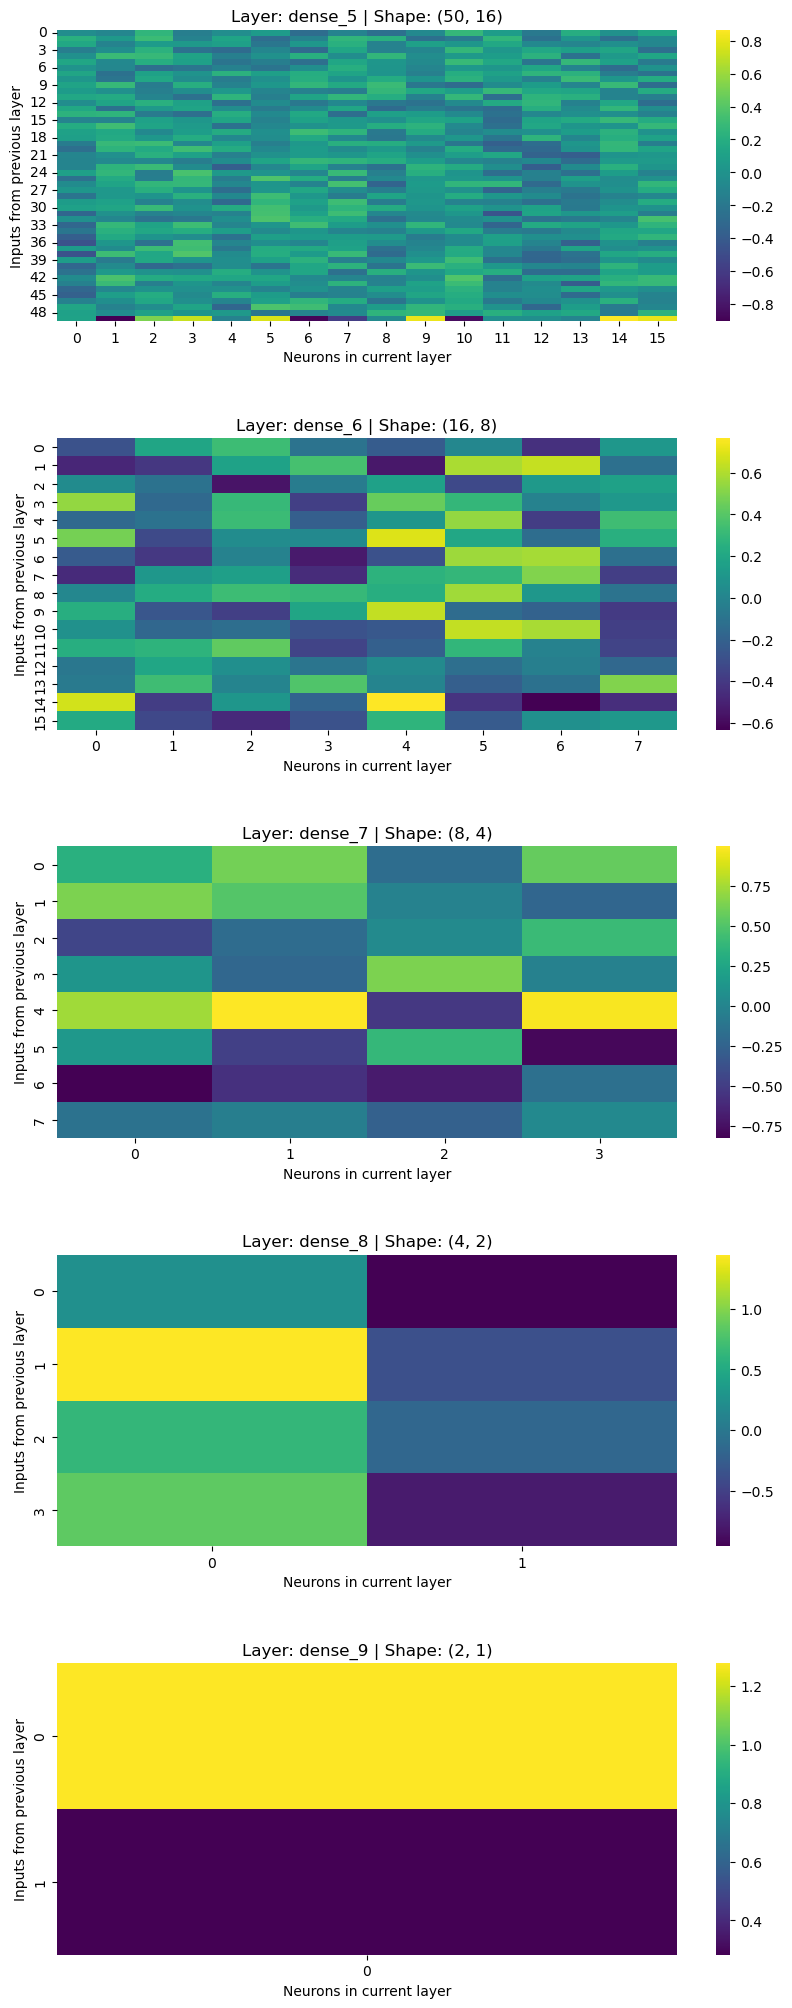

In [15]:
#分析并可视化所有层的权重矩阵
# 获取模型中所有的层（过滤掉非 Dense 层，如果有的话）
dense_layers = [layer for layer in model.layers if 'dense' in layer.name]

# 创建画布：根据层数动态调整子图数量
fig, axes = plt.subplots(len(dense_layers), 1, figsize=(10, 5 * len(dense_layers)))
plt.subplots_adjust(hspace=0.4)

for i, layer in enumerate(dense_layers):
    # 提取权重 [weights, biases]
    weights, biases = layer.get_weights()
    
    # 在对应的子图中绘制热力图
    sns.heatmap(weights, ax=axes[i], cmap='viridis', annot=False, cbar=True)
    
    axes[i].set_title(f"Layer: {layer.name} | Shape: {weights.shape}")
    axes[i].set_xlabel("Neurons in current layer")
    axes[i].set_ylabel("Inputs from previous layer")

plt.show()

In [17]:
#保存模型为Keras的标准格式
model.save('model/parity_model.keras')

#模拟在另一个程序中加载并预测
loaded_model = tf.keras.models.load_model('model/parity_model.keras')

def predict_parity(num: int)-> str:
    bin_str = [int(bit) for bit in format(num, '050b')]#将输入数字转化为50位的二进制字符串，并转化为列表
    input_data = np.array([bin_str], dtype=np.float32)

    prediction = loaded_model.predict(input_data)
    return "这个数是一个奇数！！！" if prediction[0][0] > 0.5 else "这个数是一个偶数！！！"

#随便考考模型
while (True):
    user_input = input("请输入一个整数(输入-1退出)")
    if user_input == "-1":
        print("退出")
        break
    else:
        try:
            num = int(user_input)
            result = predict_parity(num)
            print(result)
        except ValueError:
            print("请输入一个有效的整数！")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
这个数是一个偶数！！！
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
这个数是一个偶数！！！
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
这个数是一个奇数！！！
退出
